In [ ]:
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import os
import torchvision.transforms as T
from torch.utils.data import Dataset
from pathlib import Path
from torchvision import transforms
import matplotlib.pyplot as plt
from torch.utils.data import ConcatDataset, random_split, DataLoader
from torchvision.transforms import InterpolationMode

# Dataset

In [ ]:
# TODO: use your own dir

lens_dir = Path("/content/NN4Lenses/Data/RawAndMock-gallery")
nonlens_dir = Path("/content/NN4Lenses/Data/Imitator-gallery")

lens_paths = [p for p in lens_dir.iterdir() if not p.name.startswith('.')]
nonlens_paths = [p for p in nonlens_dir.iterdir() if not p.name.startswith('.')]


class GalDataset(Dataset):
    def __init__(self, image_dir, label, transform=None):
        super().__init__()
        self.image_dir = Path(image_dir)
        self.label = label
        self.transform = transform
        self.images_path = [p for p in self.image_dir.iterdir() if not p.name.startswith('.')]

    def __len__(self):
        return len(self.images_path)

    def __getitem__(self, index):
        image = Image.open(self.images_path[index])
        if self.transform:
            image = self.transform(image)
        # else:
        #     image = T.ToTensor()(image)

        return image, self.label, self.images_path[index].absolute().as_posix()


lens_ds    = GalDataset(lens_dir,    1, transform=None)
notlens_ds = GalDataset(nonlens_dir, 0, transform=None)
full_ds    = ConcatDataset([lens_ds, notlens_ds])

test_ratio = 0.20
n_test     = int(len(full_ds) * test_ratio)
n_train    = len(full_ds) - n_test
train_ds, test_ds = random_split(full_ds, [n_train, n_test],
                                 generator=torch.Generator().manual_seed(42))

class TransformWrapper(Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __len__(self):              return len(self.subset)
    def __getitem__(self, index):
        image, label, path = self.subset[index]
        image = self.transform(image)
        return image, label, path

train_tf = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(25),
    T.Resize((256,256), interpolation=InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_tf   = T.Compose([
    T.Resize((256,256), interpolation=InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

train_ds = TransformWrapper(train_ds, train_tf)
val_ds   = TransformWrapper(test_ds,  val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, pin_memory=True)

# sanity-check
images, labels, *_ = next(iter(train_loader))
print(images.shape, labels[:5])

torch.Size([32, 3, 256, 256]) tensor([1, 1, 0, 1, 0])


# ResNet18 train

In [ ]:
from torchvision import models
from torchvision.models import ResNet18_Weights

model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

num_feat = model.fc.in_features          # 512 for ResNet-18
model.fc  = nn.Linear(num_feat, 2) # binary-classifier

device = "cuda" if torch.cuda.is_available() else "cpu"

model  = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

In [ ]:
def train_fn(model, loader, criterion, optimizer, device="cpu"):

    model.train()
    running_loss = 0.0
    correct      = 0
    total        = 0

    for images, labels, *_ in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds  = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

@torch.no_grad()
def test_fn(model, loader, criterion, device="cpu"):
    model.eval()

    running_loss = 0.0
    correct      = 0
    total        = 0

    for images, labels, *_ in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss   = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds   = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model  = model.to(device)

NUM_EPOCHS = 1

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_fn(
        model, train_loader, criterion, optimizer, device
    )
    val_loss,   val_acc   = test_fn(
        model, val_loader, criterion, device
    )

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}  "
          f"train loss {train_loss:.4f}  acc {train_acc:.3%}   │   "
          f"val loss {val_loss:.4f}  acc {val_acc:.3%}")



Epoch 1/1  train loss 0.2863  acc 87.097%   │   val loss 0.2983  acc 84.615%


# Evaluation

TP:   105   FP:    22
FN:    28   TN:   170
TPR (Recall): 0.7895
FPR:          0.1146
AUROC:        0.9448


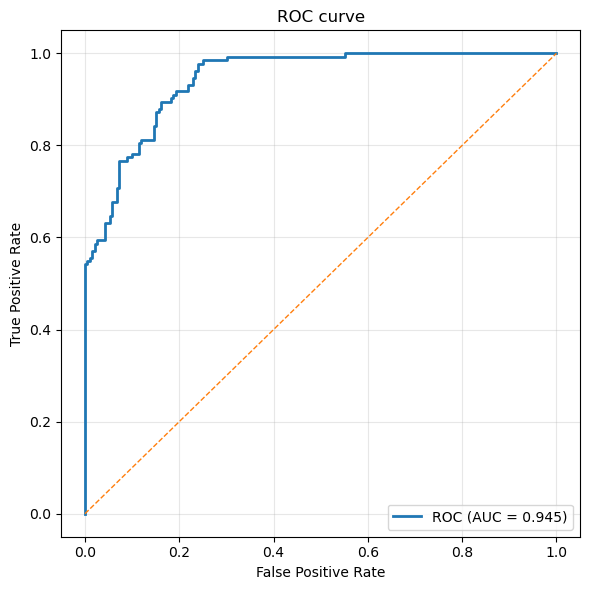

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

@torch.no_grad()
def evaluate(model, loader, device="cpu", threshold=0.5):

    model.eval()

    y_true, y_prob = [], []

    for imgs, labels, *_ in loader:
        imgs   = imgs.to(device)
        logits = model(imgs)
        probs  = torch.softmax(logits, 1)[:, 1]
        y_true.append(labels.cpu())
        y_prob.append(probs.cpu())

    y_true  = torch.cat(y_true).numpy()
    y_prob = torch.cat(y_prob).numpy()
    y_pred  = (y_prob >= threshold).astype(int)

    # fpr, tpr, _ = roc_curve(y_true, y_prob)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    auc       = roc_auc_score(y_true, y_prob)

    print(f"TP: {tp:5d}   FP: {fp:5d}")
    print(f"FN: {fn:5d}   TN: {tn:5d}")
    print(f"TPR (Recall): {tpr:.4f}")
    print(f"FPR:          {fpr:.4f}")
    print(f"AUROC:        {auc:.4f}")

    fpr_curve, tpr_curve, _ = roc_curve(y_true, y_prob)

    plt.figure(figsize=(6,6))
    plt.plot(fpr_curve, tpr_curve, lw=2, label=f"ROC (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curve")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

evaluate(model, val_loader, device)



# ResN save and use

In [ ]:
model_save_path = "resnet18-example.pth"

torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")



Model saved to resnet18-example.pth


In [ ]:
from torchvision import models
checkpoint = torch.load(model_save_path, map_location="cpu")

model = models.resnet18(weights=None)
num_feat = model.fc.in_features
model.fc  = torch.nn.Linear(num_feat, 2)
model.load_state_dict(checkpoint["model_state"])
model.eval()
device = "mps" if torch.backends.mps.is_available() else "cpu"
model.to(device)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# use the same method predict_and_save() as SimpleCNN